In [ ]:
!pip install diffusers transformers accelerate scipy


In [ ]:
import torch
import numpy as np
from diffusers import AudioDiffusionPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = AudioDiffusionPipeline.from_pretrained(
    "teticio/audio-diffusion-256",
    torch_dtype=torch.float32
).to(device)


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

unet/diffusion_pytorch_model.bin:   0%|          | 0.00/455M [00:00<?, ?B/s]

mel_config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/949 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--teticio--audio-diffusion-256/snapshots/a098cdacf70bcbc28c6f2927824e18792f756f8f/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--teticio--audio-diffusion-256/snapshots/a098cdacf70bcbc28c6f2927824e18792f756f8f/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Expected types for unet: (<class 'diffusers.models.unets.unet_2d_condition.UNet2DConditionModel'>,), got <class 'diffusers.models.unets.unet_2d.UNet2DModel'>.


In [ ]:
def generate_diffusion_impact(duration=0.15, sr=16000):
    audio = pipe(batch_size=1).audios[0]  # diffusion output

    audio = np.array(audio, dtype=np.float32)

    # FIX 1: collapse to mono
    if audio.ndim > 1:
        audio = np.mean(audio, axis=0)

    target_len = int(duration * sr)

    # FIX 2: trim or pad
    if len(audio) > target_len:
        audio = audio[:target_len]
    else:
        audio = np.pad(audio, (0, target_len - len(audio)))

    # FIX 3: normalize
    audio /= np.max(np.abs(audio) + 1e-6)
    return audio


In [ ]:
def synth_with_diffusion(sr, duration, impacts):
    canvas = np.zeros(int(sr * duration), dtype=np.float32)

    for t in impacts:
        start = int(t * sr)
        impact = generate_diffusion_impact()

        end = min(start + len(impact), len(canvas))
        canvas[start:end] += impact[:end-start]

    canvas /= np.max(np.abs(canvas) + 1e-6)
    return canvas


In [ ]:
!pip install opencv-python librosa soundfile scipy torch torchvision


In [ ]:
import os, cv2, subprocess
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import torch
from scipy.signal import savgol_filter, find_peaks


In [ ]:
import json

kaggle_dict = {
    "username": "iam.asr999",
    "key": "KGAT_b3652dfd20ba15068c7faedc1f8523a5"
}

with open("/content/kaggle.json", "w") as f:
    json.dump(kaggle_dict, f)

print("kaggle.json created")


kaggle.json created


In [ ]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d abdallahwagih/ucf101-videos


Dataset URL: https://www.kaggle.com/datasets/abdallahwagih/ucf101-videos
License(s): apache-2.0
 94% 390M/415M [00:05<00:00, 61.3MB/s]
100% 415M/415M [00:05<00:00, 73.5MB/s]


In [ ]:
!unzip /content/ucf101-videos.zip

Archive:  /content/ucf101-videos.zip
  inflating: test.csv                
  inflating: test/v_CricketShot_g01_c01.avi  
  inflating: test/v_CricketShot_g01_c02.avi  
  inflating: test/v_CricketShot_g01_c03.avi  
  inflating: test/v_CricketShot_g01_c04.avi  
  inflating: test/v_CricketShot_g01_c05.avi  
  inflating: test/v_CricketShot_g01_c06.avi  
  inflating: test/v_CricketShot_g01_c07.avi  
  inflating: test/v_CricketShot_g02_c01.avi  
  inflating: test/v_CricketShot_g02_c02.avi  
  inflating: test/v_CricketShot_g02_c03.avi  
  inflating: test/v_CricketShot_g02_c04.avi  
  inflating: test/v_CricketShot_g02_c05.avi  
  inflating: test/v_CricketShot_g02_c06.avi  
  inflating: test/v_CricketShot_g02_c07.avi  
  inflating: test/v_CricketShot_g03_c01.avi  
  inflating: test/v_CricketShot_g03_c02.avi  
  inflating: test/v_CricketShot_g03_c03.avi  
  inflating: test/v_CricketShot_g03_c04.avi  
  inflating: test/v_CricketShot_g03_c05.avi  
  inflating: test/v_CricketShot_g03_c06.avi  
  inf

In [ ]:
VIDEO_DIR = "/content/train"
OUT_DIR = "/content/output"
os.makedirs(OUT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
SR = 16000


In [ ]:
SILENT_DIR = "/content/silent_videos"
os.makedirs(SILENT_DIR, exist_ok=True)


In [ ]:
def remove_audio(input_video, output_video):
    subprocess.run([
        "ffmpeg", "-y",
        "-i", input_video,
        "-an",
        "-c:v", "copy",
        output_video
    ], check=True)


In [ ]:
def extract_motion(video_path):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)

    ret, prev = cap.read()
    prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)

    flow_energy = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        flow = cv2.calcOpticalFlowFarneback(
            prev_gray, gray,
            None, 0.5, 3, 15, 3, 5, 1.2, 0
        )

        mag, _ = cv2.cartToPolar(flow[...,0], flow[...,1])
        flow_energy.append(np.mean(mag))

        prev_gray = gray

    cap.release()
    return np.array(flow_energy), fps. [ 0.1, 0.4, -0.2, -0.8, 0.3, ... ]



In [ ]:
import numpy as np
from scipy.signal import savgol_filter, find_peaks

def smooth(x):
    if len(x) < 11:
        return x
    return savgol_filter(x, 11, 3)


def segment_flow_bursts(flow, ratio=0.5):
    thresh = ratio * np.max(flow)
    active = flow > thresh

    bursts = []
    start = None

    for i, a in enumerate(active):
        if a and start is None:
            start = i
        elif not a and start is not None:
            if i - start > 8:
                bursts.append((start, i))
            start = None

    if start is not None:
        bursts.append((start, len(flow) - 1))

    return bursts


def detect_impacts(flow, fps):
    """
    Detect impact times (seconds) using:
    - optical flow magnitude
    - burst segmentation
    - first sharp rise in motion per burst
    """

    f = smooth(flow)
    df = np.gradient(f)   # motion slope

    bursts = segment_flow_bursts(f)
    impacts = []

    PERCEPTUAL_LEAD = 2 / fps

    for s, e in bursts:
        seg = df[s:e]

        if len(seg) < int(0.3 * fps):
            continue

        peaks, _ = find_peaks(
            seg,
            height=0.4 * np.max(seg),
            distance=int(0.3 * fps)
        )

        if len(peaks) == 0:
            continue

        # take FIRST sharp rise only
        p = peaks[0]
        idx = s + p

        impact_time = idx / fps - PERCEPTUAL_LEAD
        impacts.append(max(0.0, impact_time))

    return impacts


In [ ]:
def synth_punch(sr, duration, impacts):
    audio = np.zeros(int(sr * duration))

    for t in impacts:
        start = int(t * sr)
        length = int(0.12 * sr)

        noise = np.random.randn(length)
        env = np.exp(-np.linspace(0, 6, length))
        punch = noise * env * 0.9

        end = min(start + length, len(audio))
        audio[start:end] += punch[:end-start]

    return np.clip(audio, -1, 1)


In [ ]:
videos = sorted([v for v in os.listdir(VIDEO_DIR) if v.endswith(".avi")])

for v in videos[:2]:
    original = os.path.join(VIDEO_DIR, v)
    silent = os.path.join(SILENT_DIR, v)

    if not os.path.exists(silent):
        remove_audio(original, silent)

    path = silent

    print("Processing:", v)

    flow, fps = extract_motion(path)
    impacts = detect_impacts(flow, fps)

    if not impacts:
        impacts = [0.5]

    duration = len(flow) / fps
    # audio = synth_punch(SR, duration, impacts)
    audio = synth_with_diffusion(SR, duration, impacts)


    name = os.path.splitext(v)[0]
    wav = f"{OUT_DIR}/{name}.wav"
    mp4 = f"{OUT_DIR}/{name}_with_audio.mp4"

    sf.write(wav, audio, SR)

    subprocess.run([
        "ffmpeg","-y",
        "-i", path,
        "-i", wav,
        "-c:v","copy",
        "-c:a","aac",
        "-af","adelay=0|0",
        "-shortest",
        mp4
    ])

print("DONE →", OUT_DIR)


Processing: v_CricketShot_g08_c01.avi


  0%|          | 0/1000 [00:00<?, ?it/s]

Processing: v_CricketShot_g08_c02.avi


  0%|          | 0/1000 [00:00<?, ?it/s]

DONE → /content/output


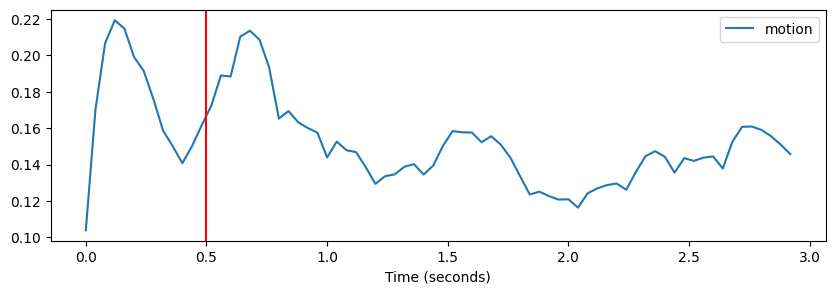

Detected impacts: 1


In [ ]:
time = np.arange(len(flow)) / fps

plt.figure(figsize=(10,3))
plt.plot(time, smooth(flow), label="motion")

for t in impacts:
    plt.axvline(t, color="r")

plt.xlabel("Time (seconds)")
plt.legend()
plt.show()

print("Detected impacts:", len(impacts))
